In [1]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import keyring
from io import StringIO
import requests
from matplotlib.ticker import FuncFormatter, MaxNLocator

import eikon as ek
from pydatastream import Datastream

from scipy.stats import ttest_ind, ttest_ind_from_stats
from scipy.special import stdtr

# Connection to Datastream

In [2]:
# --- Log ind ---
ek.set_app_key('035d2f1682244553ba7f239ce9e8d281142013dd')
service = "Datastream"
DS_USERNAME = "ZNYK749" #Ændre denne
DS_PASSWORD = keyring.get_password(service, DS_USERNAME)

if DS_USERNAME and DS_PASSWORD:
    DS = Datastream(username=DS_USERNAME, password=DS_PASSWORD)
else:
    DS = None
    print("WARNING: DS_USERNAME/DS_PASSWORD ikke sat som miljøvariabler.")

# Dates

In [3]:
pd.set_option('display.max_rows', 10)

start = '20060915'
end = datetime.today().strftime('%Y%m%d')  # Sætter automatisk til dags dato
start_ds = start
end_ds = end

source = 'datastream'
fx = 'DKK'
width_bar = 1

N = 1
ind = np.arange(N)

# Index

In [5]:
# Define a helper function to simplify fetching and renaming data
def fetch_and_rename_data(symbol, column_name):
    data = DS.get_price([symbol], date_from=start_ds, date_to=end_ds)
    data = data.rename(columns={'P': column_name})
    return data

# Fetch and merge equity data
data = pd.DataFrame(index=pd.date_range(start_ds, end_ds, freq='B'))

equity_data = [
    ('M1AFCS$(MSNR)~DKK', 'MSCI World Consumer Staples'),
    ('M1AFID$(MSNR)~DKK', 'MSCI World Industrials'),
    ('M1AFHC$(MSNR)~DKK', 'MSCI World Health Care'),
    ('M1AFM1$(MSNR)~DKK', 'MSCI World Materials'),
    ('M1AFIT$(MSNR)~DKK', 'MSCI World IT'),
    ('M1AFFN$(MSNR)~DKK', 'MSCI World Financials'),
    ('M1AFCD$(MSNR)~DKK', 'MSCI World Consumer Discretionary'),
    ('M1AFE1$(MSNR)~DKK', 'MSCI World Energy'),
    ('M1AFR1$(MSNR)~DKK', 'MSCI World Real Estate'),
    ('M1AFU1$(MSNR)~DKK', 'MSCI World Utilities'),
    ('M1AFT1$(MSNR)~DKK', 'MSCI World Communication Services')
]

for symbol, column_name in equity_data:
    equity = fetch_and_rename_data(symbol, column_name)
    data = pd.merge(data, equity, left_index=True, right_index=True)

# Fetch and merge bond data

bond_data = [
    #('ERC0(ML:RI#T)', 'European IG'),
    #('HW00(ML:RIHDEUR)', 'Global HY'),
    #('NYKMTSH(RI)', 'Danish Mortgage Bonds Short Index'),
    #('NYKMTLM(RI)', 'Danish Mortgage Bonds Long Index'),
    #('NDGVT5Y(RI)', 'Nordea 5-year index'),
    #('NDGVT2Y(RI)', 'Nordea 2-year index'),
    #('NDGVT7Y(RI)', 'Nordea 7-year index'),
    #('BMUS10Y(RI)~DKK', 'US Treasuries')
]

for symbol, column_name in bond_data:
    bond = fetch_and_rename_data(symbol, column_name)
    data = pd.merge(data, bond, left_index=True, right_index=True)

# Fetch and merge additional data
ust_usd = fetch_and_rename_data('BMUS10Y(RI)', 'US Treasuries in USD')
min_vol = fetch_and_rename_data('(MSDWME$(MSNR))~DKK', 'MSCI World Min Vol')

data = pd.merge(data, ust_usd, left_index=True, right_index=True)
data = pd.merge(data, min_vol, left_index=True, right_index=True)


# Store equity data
equities = data.copy()
print(equities.head())

            MSCI World Consumer Staples  MSCI World Industrials  \
2006-09-15                       841.73                  775.86   
2006-09-18                       838.79                  775.63   
2006-09-19                       838.88                  773.55   
2006-09-20                       843.17                  774.23   
2006-09-21                       838.53                  771.59   

            MSCI World Health Care  MSCI World Materials  MSCI World IT  \
2006-09-15                  630.56               1309.55        435.338   
2006-09-18                  629.83               1316.75        435.101   
2006-09-19                  627.88               1307.53        432.569   
2006-09-20                  631.49               1305.79        437.119   
2006-09-21                  628.79               1309.42        434.225   

            MSCI World Financials  MSCI World Consumer Discretionary  \
2006-09-15                 863.08                             722.01   
20

In [7]:
def fetch_and_rename_data(symbol, column_name):
    data = DS.get_price([symbol], date_from=start_ds, date_to=end_ds)
    data = data.rename(columns={'P': column_name})
    return data

gics_sectors = [
    ('M1AFCS$(MSNR)~DKK', 'Consumer Staples'),
    ('M1AFID$(MSNR)~DKK', 'Industrials'),
    ('M1AFHC$(MSNR)~DKK', 'Health Care'),
    ('M1AFM1$(MSNR)~DKK', 'Materials'),
    ('M1AFIT$(MSNR)~DKK', 'IT'),
    ('M1AFFN$(MSNR)~DKK', 'Financials'),
    ('M1AFCD$(MSNR)~DKK', 'Consumer Discretionary'),
    ('M1AFE1$(MSNR)~DKK', 'Energy'),
    ('M1AFR1$(MSNR)~DKK', 'Real Estate'),
    ('M1AFU1$(MSNR)~DKK', 'Utilities'),
    ('M1AFT1$(MSNR)~DKK', 'Communication Services'),
]

gics_data = None

for symbol, column_name in gics_sectors:
    series = fetch_and_rename_data(symbol, column_name)
    gics_data = series if gics_data is None else pd.merge(
        gics_data, series, left_index=True, right_index=True, how='outer')

print(gics_data.head())
print(gics_data.shape)

            Consumer Staples  Industrials  Health Care  Materials       IT  \
2006-09-15            841.73       775.86       630.56    1309.55  435.338   
2006-09-18            838.79       775.63       629.83    1316.75  435.101   
2006-09-19            838.88       773.55       627.88    1307.53  432.569   
2006-09-20            843.17       774.23       631.49    1305.79  437.119   
2006-09-21            838.53       771.59       628.79    1309.42  434.225   

            Financials  Consumer Discretionary   Energy  Real Estate  \
2006-09-15      863.08                  722.01  1199.69          NaN   
2006-09-18      861.05                  718.51  1219.44          NaN   
2006-09-19      859.03                  718.19  1208.05          NaN   
2006-09-20      863.02                  721.57  1187.84          NaN   
2006-09-21      862.68                  722.41  1193.56          NaN   

            Utilities  Communication Services  
2006-09-15     886.64                  517.15  
20

In [9]:
#Print GICS sector data to csv in the data folder
gics_data.to_csv('data/gics_sector_data.csv')
# Calculate returns and export to CSV
gics_returns = gics_data.pct_change()
gics_returns.to_csv('data/gics_sector_returns.csv')

# Futures

### DS.Get_price()(SKAL IKKE BRUGES)

In [5]:
def fetch_futures_data(symbol, column_name):
    data = DS.get_price([symbol], date_from=start_ds, date_to=end_ds)
    data = data.rename(columns={'P': column_name})
    return data

# Start med en tom dataframe — ingen foruddefineret index
futures_data = None

equity_futures = [
    ('ISMCS00', 'S&P 500'),          # USD
    ('CENCS00', 'NASDAQ 100'),       # USD
    ('GEXCS00', 'Euro Stoxx 50'),     # EUR
    #('ONACS00', 'Nikkei 225', 'PS'),      # JPY             #Af en eller anden årsag jeg ikke kender, så kan jeg ikke hive denne ud her i Datastream
    #('SCNCS00' , 'FTSE China A50'), # CNY            #Af en eller anden årsag jeg ikke kender, så kan jeg ikke hive denne ud her i Datastream
    ('GDXCS00', 'DAX'),              # EUR
    ('HSICS00', 'Hang Seng'),        # HKD
    ('LSXCS00', 'FTSE 100'),          # GBP
    ('BSXCS00', 'India')             # Ekstra
]

bond_futures = [
    ('GGECS00', 'Euro Bund 10Y'),    # EUR
    ('GBECS00', 'EURO BOBL 5Y'),      # EUR
    ('GEBCS00', 'EURO SCHATZ 2Y'),    # EUR
    ('CTTCS00', 'US T-Note 10Y'),    # USD
    ('CTFCS00', 'US T-Note 5Y'),     # USD
    ('CTECS00', 'US T-Note 2Y')     # USD
]

for symbol, column_name in equity_futures + bond_futures:
    series = fetch_futures_data(symbol, column_name)
    if futures_data is None:
        futures_data = series
    else:
        futures_data = pd.merge(futures_data, series,
                                left_index=True, right_index=True,
                                how='outer')

print(futures_data.head())
print(futures_data.shape)

            S&P 500  NASDAQ 100  Euro Stoxx 50     DAX  Hang Seng  FTSE 100  \
2006-09-15   1335.7     1653.75         3827.0  5978.5     2292.0    5907.5   
2006-09-18   1330.0     1653.25         3830.0  5976.0     2292.0    5937.0   
2006-09-19   1334.0     1642.75         3790.0  5921.5     2292.0    5839.5   
2006-09-20   1334.8     1663.50         3861.0  6004.5     2292.0    5905.5   
2006-09-21   1338.2     1655.00         3845.0  5969.0     2292.0    5910.0   

              India  Euro Bund 10Y  EURO BOBL 5Y  EURO SCHATZ 2Y  \
2006-09-15  11990.0         117.24        109.52          103.82   
2006-09-18  12065.0         117.09        109.41          103.77   
2006-09-19  11922.0         117.50        109.63          103.88   
2006-09-20  12130.0         117.39        109.57          103.85   
2006-09-21  12290.0         118.02        109.94          103.98   

            US T-Note 10Y  US T-Note 5Y  US T-Note 2Y  
2006-09-15       107.0000      104.8438      101.9688  
2006

### DS.fetch() (SKAL IKKE BRUGES)

In [12]:
def fetch_futures_data(symbol, column_name, field='P'):
    try:
        data = DS.fetch(symbol, fields=field,
                        date_from=start_ds, date_to=end_ds, freq='D')
        data = data.rename(columns={field: column_name})
        print(f"✓ {column_name} ({symbol}) med felt '{field}'")
        return data
    except Exception as e:
        print(f"✗ {column_name} ({symbol}) fejler: {e}")
        return None

# Test Nikkei med PS
test = fetch_futures_data('ONACS00', 'Nikkei 225', field='PS')
print(test.head())

✓ Nikkei 225 (ONACS00) med felt 'PS'
            Nikkei 225
2000-12-29       13760
2001-01-01       13760
2001-01-02       13760
2001-01-03       13760
2001-01-04       13650


### Henter med "P" først, og hvis det fejler, så prøver vi "PO", og hvis det også fejler, så "PS"

In [6]:
def clean_price_series(data, column_name, jump_threshold=2.0):
    """
    Detekterer og back-adjusterer kontraktskift-fejl i en prisserie.

    jump_threshold: Faktor hvor et prisjump anses som fejl (default: 2x = 200% ændring).
    Reelle daglige futures-afkast overstiger aldrig denne faktor.
    """
    series = data[column_name].copy()

    # Beregn daglige prisratioer (ikke afkast, men faktorer)
    ratios = series / series.shift(1)

    # Find datoer hvor prisen hopper mere end threshold i begge retninger
    jump_dates = series.index[
        (ratios > jump_threshold) | (ratios < 1 / jump_threshold)
    ]

    if len(jump_dates) == 0:
        return data  # Ingen fejl fundet

    for jump_date in jump_dates:
        factor = ratios.loc[jump_date]
        print(f"  ⚠ Kontraktskift detekteret i '{column_name}' på {jump_date.date()}: "
              f"prisjump faktor {factor:.2f}x — back-adjusterer historik")

        # Juster alle tidligere priser med samme faktor så serien bliver kontinuert
        series.loc[series.index < jump_date] *= factor

    data = data.copy()
    data[column_name] = series
    return data


def fetch_futures_data(symbol, column_name, fields_to_try=None):
    if fields_to_try is None:
        fields_to_try = ['P', 'PO', 'PS']

    for field in fields_to_try:
        try:
            data = DS.fetch(symbol, fields=field,
                            date_from=start_ds, date_to=end_ds, freq='D')

            if data is not None and not data.empty and data.iloc[:, 0].notna().any():
                data = data.rename(columns={field: column_name})
                data = clean_price_series(data, column_name)  # <-- Clean lige efter fetch
                print(f"✓ {column_name} ({symbol}) hentet med felt '{field}'")
                return data
            else:
                print(f"  → {symbol} med felt '{field}' returnerede tom/NaN data, prøver næste...")

        except Exception as e:
            print(f"  → {symbol} med felt '{field}' fejlede: {e}, prøver næste...")

    print(f"✗ {column_name} ({symbol}) kunne ikke hentes med nogen af felterne: {fields_to_try}")
    return None

# Definer futures med valgfri field-override
equity_futures = [
    ('ISMCS00', 'S&P 500'),
    ('CENCS00', 'NASDAQ 100'),
    ('GEXCS00', 'Euro Stoxx 50'),
    ('ONACS00', 'Nikkei 225'),       # Vil automatisk falde tilbage til PS/PO
    ('SCNCS00', 'FTSE China A50'),   # Vil automatisk falde tilbage til PS/PO
    ('GDXCS00', 'DAX'),
    ('HSICS00', 'Hang Seng', ['PS', 'P']),
    ('LSXCS00', 'FTSE 100'),
    #('BSXCS00', 'India')
]

bond_futures = [
    ('GGECS00', 'EURO BUND 10Y'),
    ('GBECS00', 'EURO BOBL 5Y'),
    ('GEBCS00', 'EURO SCHATZ 2Y'),
    ('CTTCS00', 'US T-Note 10Y'),
    ('CTFCS00', 'US T-Note 5Y'),
    ('CTECS00', 'US T-Note 2Y')
]

# Bonds bruger kun 'P' — ingen grund til at prøve andre fields
futures_data = None

for item in equity_futures:
    symbol, column_name = item[0], item[1]
    fields = item[2] if len(item) > 2 else ['P', 'PS', 'PO']

    series = fetch_futures_data(symbol, column_name, fields_to_try=fields)
    if series is not None:
        futures_data = series if futures_data is None else pd.merge(
            futures_data, series, left_index=True, right_index=True, how='outer')

for symbol, column_name in bond_futures:
    series = fetch_futures_data(symbol, column_name, fields_to_try=['P'])
    if series is not None:
        futures_data = series if futures_data is None else pd.merge(
            futures_data, series, left_index=True, right_index=True, how='outer')

✓ S&P 500 (ISMCS00) hentet med felt 'P'
✓ NASDAQ 100 (CENCS00) hentet med felt 'P'
✓ Euro Stoxx 50 (GEXCS00) hentet med felt 'P'
  → ONACS00 med felt 'P' fejlede: "ONACS00"("P"): $$ER: E100,INVALID CODE OR EXPRESSION ENTERED, prøver næste...
✓ Nikkei 225 (ONACS00) hentet med felt 'PS'
  → SCNCS00 med felt 'P' fejlede: "SCNCS00"("P"): $$ER: E100,INVALID CODE OR EXPRESSION ENTERED, prøver næste...
✓ FTSE China A50 (SCNCS00) hentet med felt 'PS'
✓ DAX (GDXCS00) hentet med felt 'P'
✓ Hang Seng (HSICS00) hentet med felt 'PS'
✓ FTSE 100 (LSXCS00) hentet med felt 'P'
✓ EURO BUND 10Y (GGECS00) hentet med felt 'P'
✓ EURO BOBL 5Y (GBECS00) hentet med felt 'P'
✓ EURO SCHATZ 2Y (GEBCS00) hentet med felt 'P'
✓ US T-Note 10Y (CTTCS00) hentet med felt 'P'
✓ US T-Note 5Y (CTFCS00) hentet med felt 'P'
✓ US T-Note 2Y (CTECS00) hentet med felt 'P'


### Eksport til CSV

In [7]:
#Write the futures data to a CSV file
futures_data.to_csv('data/futures_data.csv')

### Regner returns & Eksportere til CSV

In [8]:
# Beregner returns
returns = futures_data.pct_change()

In [9]:
# Eksporter returns til CSV i data mappen
returns.to_csv('data/futures_returns.csv')

### Plot data og tjek for outliers

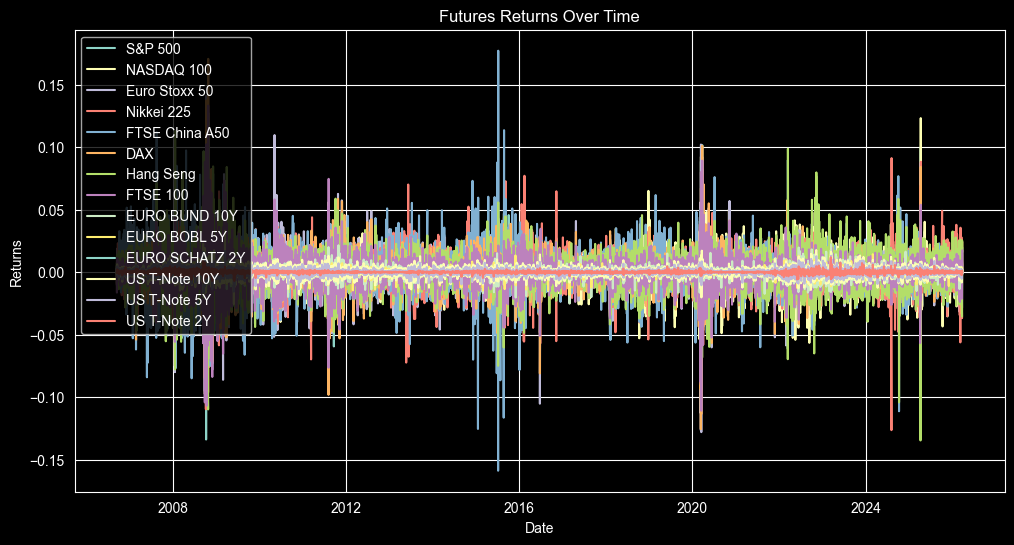

In [10]:
#Plot returns
plt.figure(figsize=(12, 6))
for column in returns.columns:
    plt.plot(returns.index, returns[column], label=column)
plt.title('Futures Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

In [11]:
# Se de værste outliers
threshold = 0.15  # 15% dagligt afkast er ekstremt for futures
outliers = returns[returns.abs() > threshold]
print(outliers.stack().dropna().sort_values(ascending=False))

2015-07-09  FTSE China A50    0.177018
2008-10-28  DAX               0.170536
2015-07-08  FTSE China A50   -0.158841
dtype: float64


# FX kurslister

In [24]:
fx_data_list = [
    ('USDDK.', 'USD_DKK'),
    ('EURDK.', 'EUR_DKK'),
    ('GBPDK.', 'GBP_DKK'),
    ('HKDDK.', 'HKD_DKK'),
    ('INDDK.', 'INR_DKK'),
]

fx_data = None
for symbol, column_name in fx_data_list:
    try:
        series = fetch_futures_data(symbol, column_name)
        if fx_data is None:
            fx_data = series
        else:
            fx_data = pd.merge(fx_data, series,
                               left_index=True, right_index=True,
                               how='outer')
        print(f"✓ {column_name}")
    except Exception as e:
        print(f"✗ {column_name} fejler — prøv anden kode")

✗ USD_DKK fejler — prøv anden kode
✗ EUR_DKK fejler — prøv anden kode
✗ GBP_DKK fejler — prøv anden kode
✗ HKD_DKK fejler — prøv anden kode
✗ INR_DKK fejler — prøv anden kode
